[<< Sommaire QC](../README.md) | [Précédent : QC-Py-28b-Macro-Cycle-Regimes <<](./QC-Py-28b-Macro-Cycle-Regimes.ipynb) | [Suivant : QC-Py-29-Derivatives-Valuation >>](./QC-Py-29-Derivatives-Valuation.ipynb)

# QC-Py-28c - Prétraitement de facteurs pour la détection de régime

> **[HYBRIDE LOCAL + QC CLOUD]** Les parties 1 à 6 s'exécutent **localement** (numpy / pandas / scikit-learn / LightGBM / statsmodels), sur une série de prix **synthétique à régimes**, à graine fixée — c'est la convention des notebooks de cette série. La partie 8 donne le code `QuantBook` de référence, à exécuter dans l'IDE Cloud.

**Source** : livre *Hands-On AI Trading* (Jared Broad), chapitre `06 Applied Machine Learning`, exemple **02 — Factor Preprocessing Techniques for Regime Detection**. Le livre ne fournit qu'un `research.ipynb` de recherche, sans algorithme LEAN. Inventaire : [BOOK_MAPPING.md](../BOOK_MAPPING.md), ligne `06/02` (issue #18958).

**Ce que le livre cherche à montrer** : le prétraitement des facteurs (stationnarisation, standardisation, ACP) change l'exactitude mesurée du classifieur. **Ce que ce port ajoute** : la mesure qui manque à cette démonstration — la comparaison à la classe majoritaire, la dispersion inter-graines, et un second jeu de facteurs réellement informatifs. Les résultats sont en partie 7.

## Ce que fait l'exemple 06/02 du livre

Cinq parties, dans l'ordre du notebook du livre :

| Partie | Contenu | Outil |
|---|---|---|
| 1 | Construire la cible : signe du rendement à 5 jours de SPY | `qb.history` (QuantBook) |
| 2 | Facteurs **aléatoires** (dont un rendu non stationnaire par `cumsum`) → exactitude brute | `lightgbm` (forêt), `train_test_split` |
| 3 | Test de stationnarité puis **différenciation fractionnaire** (FFD, López de Prado) → exactitude | `adfuller`, FFD maison |
| 4 | **Standardisation** (`StandardScaler`) → exactitude | scikit-learn |
| 5 | **ACP** (`PCA`) → exactitude | scikit-learn |

Le livre rapporte, à chaque étape, une exactitude (`accuracy_score`) et conclut que le prétraitement fait bouger le chiffre. Il ne rapporte **jamais** la classe majoritaire : rien, dans son notebook, ne permet de dire si l'exactitude mesurée est un signal ou le simple taux de base de la fenêtre de test.

## Ce que ce port mesure en plus

1. **La classe majoritaire**, calculée sur la **fenêtre de test** et non sur le tout — c'est la seule comparaison qui ait un sens pour une exactitude hors échantillon.
2. La **part de classe 1 prédite** : un modèle qui prédit « toujours 0 » atteint exactement la majoritaire ; le montrer évite de lire une exactitude comme une compétence.
3. La **dispersion inter-graines** (4 graines : 0, 1, 7, 42) — sans elle, un écart de 0,01 entre deux variantes n'est pas interprétable.
4. Un **second jeu de facteurs réellement informatifs** (momentum et volatilité réalisée, dérivés du prix), à côté du jeu aléatoire du livre. C'est ce qui distingue « le prétraitement change un chiffre » de « le prétraitement change une performance ».

In [1]:
# Setup : imports, constantes et graines
import warnings
from datetime import datetime

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True

SEED = 42           # graine de la série de prix et des facteurs du livre
N_DAYS = 6300       # ~25 ans de jours ouvrés
HORIZON = 5         # rendement à 5 jours, comme le livre
SEEDS_MODEL = (0, 1, 7, 42)   # dispersion inter-graines (section 7)

print(f"numpy {np.__version__} | pandas {pd.__version__} | lightgbm {lgb.__version__}")
print(f"graine={SEED} jours={N_DAYS} horizon={HORIZON}")

numpy 2.3.5 | pandas 3.0.2 | lightgbm 4.6.0
graine=42 jours=6300 horizon=5


## Partie 1 — La cible : signe du rendement à 5 jours

Le livre ouvre un `QuantBook` et lit SPY de 2000 à 2024 : `label = open.pct_change(5).shift(-5) > 0`. Cette ligne dit « le prix a-t-il monté dans les cinq jours qui **suivent** » — c'est bien une cible prédictive, et non un rendement réalisé.

Comme aucune donnée de marché n'est versionnée dans ce dépôt (un seul CSV, crypto, sous `datasets/`), la partie locale tourne sur une série **synthétique à régimes** : trois états (haussier à volatilité basse, baissier à volatilité haute, range) enchaînés par une chaîne de Markov persistante. Le livre fait tourner sa démonstration sur des facteurs aléatoires — la partie locale reste donc fidèle à son objet, tout en donnant au lecteur une cible dont l'équilibre des classes soit réaliste.

In [2]:
def synthetic_regime_prices(n_days=N_DAYS, seed=SEED):
    """Série de prix synthétique à trois régimes, déterministe.

    Les régimes sont enchaînés par une chaîne de Markov persistante : un
    régime dure en moyenne plusieurs dizaines de jours, ce qui rend la
    cible (signe du rendement à 5 jours) partiellement prévisible — sans
    quoi la comparaison des prétraitements porterait sur du bruit pur.

    Returns:
        (prix, regime) : deux Series indexées sur des jours ouvrés.
    """
    rng = np.random.default_rng(seed)
    # régime 0 : haussier, volatilité basse ; 1 : baissier, volatilité haute ; 2 : range
    mus = np.array([0.00055, -0.00075, 0.00002])
    sigmas = np.array([0.008, 0.020, 0.011])
    P = np.array([[0.985, 0.007, 0.008],
                  [0.010, 0.975, 0.015],
                  [0.020, 0.015, 0.965]])
    states = np.empty(n_days, dtype=int)
    states[0] = 0
    for i in range(1, n_days):
        states[i] = rng.choice(3, p=P[states[i - 1]])
    returns = rng.normal(mus[states], sigmas[states])
    index = pd.bdate_range("2000-01-03", periods=n_days)
    return (pd.Series(100.0 * np.exp(np.cumsum(returns)), index=index, name="close"),
            pd.Series(states, index=index, name="regime"))


prices, regime = synthetic_regime_prices()
print(f"{len(prices)} jours ouvrés, du {prices.index[0].date()} au {prices.index[-1].date()}")
print("répartition des régimes :", dict(zip(["haussier", "baissier", "range"],
                                            np.bincount(regime.values).tolist())))

6300 jours ouvrés, du 2000-01-03 au 2024-02-23
répartition des régimes : {'haussier': 2810, 'baissier': 1485, 'range': 2005}


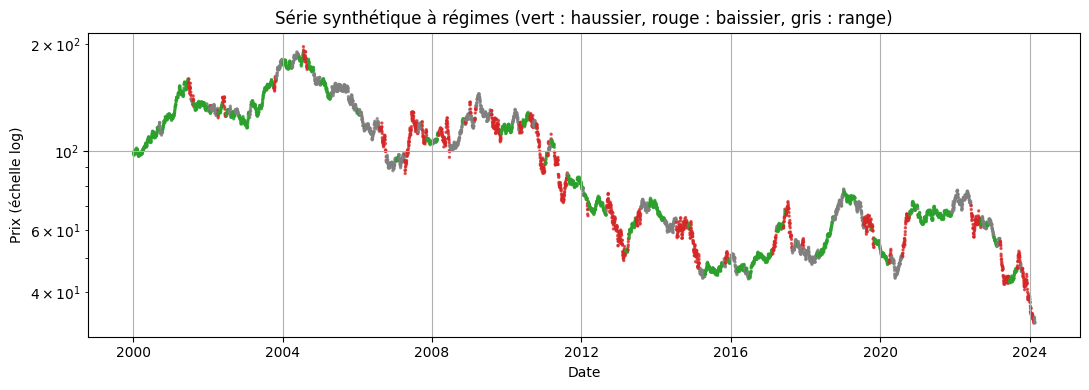

In [3]:
# Trace du prix, coloré par régime (le régime est une variable latente : le
# lecteur la voit, le modèle ne la verra jamais — il n'a que les facteurs).
colors = np.array(["tab:green", "tab:red", "tab:gray"])
fig, ax = plt.subplots()
ax.scatter(prices.index, prices.values, s=2, c=colors[regime.values], alpha=0.7)
ax.set_yscale("log")
ax.set_title("Série synthétique à régimes (vert : haussier, rouge : baissier, gris : range)")
ax.set_xlabel("Date")
ax.set_ylabel("Prix (échelle log)")
plt.tight_layout()
plt.show()

**Lecture du résultat.** L'échelle logarithmique rend les trois régimes lisibles : les segments verts montent régulièrement, les rouges descendent plus vite et plus fort (volatilité deux fois et demie supérieure), les gris stagnent. C'est cette structure qui rend la cible partiellement apprenable — un marcheur aléatoire pur donnerait une exactitude qui ne s'écarte jamais de la classe majoritaire, quelle que soit la qualité du prétraitement.

In [4]:
# La cible, exactement comme le livre : signe du rendement à HORIZON jours.
forward = prices.pct_change(HORIZON).shift(-HORIZON)
label = forward.dropna().apply(lambda x: int(x > 0))

baseline_globale = max(label.value_counts()) / len(label)
print(f"cible : {len(label)} observations")
print(label.value_counts().rename({0: "classe 0 (baisse)", 1: "classe 1 (hausse)"}).to_string())
print(f"part de classe 1        : {label.mean():.4f}")
print(f"classe majoritaire (tout) : {baseline_globale:.4f}")

cible : 6295 observations
close
classe 0 (baisse)    3161
classe 1 (hausse)    3134
part de classe 1        : 0.4979
classe majoritaire (tout) : 0.5021


**Lecture du résultat.** La cible est presque équilibrée — la classe majoritaire vaut à peine plus d'une chance sur deux sur l'ensemble de la série. C'est un piège de lecture : sur une **fenêtre** de test de 25 %, ce taux de base peut s'écarter sensiblement de 0,50, et c'est ce chiffre-là — et non celui calculé sur le tout — qui doit servir de référence. La partie 7 le mesure pour chaque variante.

### Exercice 1 — L'horizon change-t-il l'équilibre des classes ?

Le livre fixe l'horizon à 5 jours sans le justifier. Recalculez la cible pour les horizons 1, 5, 10 et 20 jours, et affichez pour chacun la part de classe 1 et la classe majoritaire. Concluez : l'équilibre des classes dépend-il fortement de l'horizon ?

**Indices**
- `# Indice` : `prices.pct_change(h).shift(-h).dropna().apply(lambda x: int(x > 0))`
- `# Indice` : la part de classe 1 est la moyenne de la série binaire
- `# Etape 1` : boucler sur les horizons
- `# Etape 2` : afficher part de classe 1 et classe majoritaire
- `# Etape 3` : conclure en une phrase

In [5]:
# Exercice 1 : équilibre des classes selon l'horizon
# TODO etudiant : boucler sur (1, 5, 10, 20) et afficher part de classe 1 + majoritaire
# Etape 1 : construire la cible pour chaque horizon
# Etape 2 : afficher part de classe 1 et classe majoritaire
# Etape 3 : conclure
equilibre_par_horizon = None  # TODO etudiant : remplacer par le tableau
print("Exercice a completer : équilibre des classes selon l'horizon")

Exercice a completer : équilibre des classes selon l'horizon


## Partie 2 — Les facteurs : deux jeux, deux questions

Le livre tire ses facteurs au hasard (`np.random.rand`) et rend le dernier non stationnaire par un `cumsum`. C'est un choix pédagogique assumé : il veut montrer **l'effet mécanique** du prétraitement, pas la performance d'un modèle. Mais il laisse le lecteur devant une ambiguïté : « l'exactitude bouge » ne dit pas « le modèle apprend ».

Ce port garde le jeu du livre et ajoute un second jeu, dérivé du prix — deux moments (20 et 60 jours) et deux volatilités réalisées (5 et 20 jours). Le contraste entre les deux jeux est le cœur de la partie 7.

In [6]:
n_obs = len(label)

# --- Jeu A : les facteurs du livre (aléatoires, dernier non stationnaire) ---
rng = np.random.default_rng(SEED - 35)
factors_random = rng.random((n_obs, 4))
factors_random[:, -1] = factors_random[:, -1].cumsum()   # marche aléatoire : I(1)

# --- Jeu B : facteurs dérivés du prix (informatifs par construction) ---
prices_aligned = prices.reindex(label.index)
returns = prices_aligned.pct_change()
factors_informative = pd.DataFrame({
    "momentum_20": prices_aligned.pct_change(20),
    "vol_realisee_20": returns.rolling(20).std(),
    "momentum_60": prices_aligned.pct_change(60),
    "vol_realisee_5": returns.rolling(5).std(),
}, index=label.index).bfill().fillna(0.0).values

print("jeu A (livre)      :", factors_random.shape)
print("jeu B (informatif) :", factors_informative.shape)
print("A - 4e facteur, min/max :", round(factors_random[:, -1].min(), 2),
      "/", round(factors_random[:, -1].max(), 2), "(dérive : non stationnaire)")

jeu A (livre)      : (6295, 4)
jeu B (informatif) : (6295, 4)
A - 4e facteur, min/max : 0.23 / 3129.56 (dérive : non stationnaire)


## Partie 3 — Stationnarité : test ADF, puis différenciation fractionnaire

Le test ADF (`adfuller`) teste l'hypothèse nulle de racine unitaire : une p-valeur faible signifie « stationnaire ». Le livre teste ses quatre facteurs, constate que le dernier ne l'est pas, et applique la **différenciation fractionnaire à fenêtre fixe** (FFD, López de Prado) : au lieu de différencier d'ordre 1 (`x[t] - x[t-1]`, qui détruit la mémoire), on cherche le plus petit ordre `d` réel qui rend la série stationnaire — la mémoire longue est conservée autant que possible.

In [7]:
for nom, jeu in (("A (livre)", factors_random), ("B (informatif)", factors_informative)):
    verdicts = []
    for j in range(jeu.shape[1]):
        p_value = adfuller(jeu[:, j], maxlag=1, regression="c", autolag=None)[1]
        verdicts.append(f"F{j}: p={p_value:.4f} {'stationnaire' if p_value <= 0.05 else 'NON stationnaire'}")
    print(f"jeu {nom:14} " + " | ".join(verdicts))

jeu A (livre)      F0: p=0.0000 stationnaire | F1: p=0.0000 stationnaire | F2: p=0.0000 stationnaire | F3: p=0.9956 NON stationnaire
jeu B (informatif) F0: p=0.0000 stationnaire | F1: p=0.0000 stationnaire | F2: p=0.0000 stationnaire | F3: p=0.0000 stationnaire


**Lecture du résultat.** Dans le jeu A, les trois premiers facteurs sont stationnaires par construction (tirage uniforme) et le quatrième — le `cumsum` — ne l'est pas : le test ADF le désigne sans ambiguïté. Dans le jeu B, les quatre facteurs sont déjà stationnaires : un momentum et une volatilité réalisée sont des **transformations en rendement** du prix, pas des niveaux. C'est une différence qui va compter : la FFD n'a rien à corriger sur le jeu B.

In [8]:
def get_weights_ffd(d, thres):
    """Poids de la différenciation fractionnaire à fenêtre fixe.

    Args:
        d: ordre de différenciation (réel, pas nécessairement entier).
        thres: seuil de troncature des poids.
    Returns:
        np.ndarray de forme (largeur, 1), du plus ancien au plus récent.
    """
    weights, k = [1.0], 1
    while True:
        next_w = -weights[-1] / k * (d - k + 1)
        if abs(next_w) < thres:
            break
        weights.append(next_w)
        k += 1
    return np.array(weights[::-1]).reshape(-1, 1)


def frac_diff_ffd(series, d, thres=1e-5):
    """Différenciation fractionnaire à fenêtre constante (López de Prado).

    Args:
        series: DataFrame d'une ou plusieurs colonnes à différencier.
        d: ordre de différenciation.
        thres: seuil de troncature des poids.
    Returns:
        DataFrame différencié ; les `largeur` premières lignes sont perdues.
    """
    weights = get_weights_ffd(d, thres)
    width = len(weights) - 1
    out = {}
    for name in series.columns:
        s = series[[name]].ffill().dropna()
        values = pd.Series(index=s.index, dtype=float)
        for i in range(width, s.shape[0]):
            loc0, loc1 = s.index[i - width], s.index[i]
            if not np.isfinite(series.loc[loc1, name]):
                continue
            values.loc[loc1] = float(np.dot(weights.T, s.loc[loc0:loc1].values)[0, 0])
        out[name] = values.dropna()
    return pd.concat(out, axis=1)


def ffd(process, thres=0.01):
    """Plus petit ordre `d` (pas de 0,1) dont la FFD passe le test ADF.

    Returns:
        (série différenciée, d retenu).
    """
    process = np.asarray(process, dtype=float)
    result = None
    for d in np.linspace(0, 1, 11):
        result = frac_diff_ffd(pd.DataFrame({"x": process}), d, thres)
        if adfuller(result["x"].values, maxlag=1, regression="c", autolag=None)[1] <= 0.05:
            return result["x"].values, float(d)
    return result["x"].values, 1.0


def stationarize(mat, thres=0.01):
    """Applique `ffd` colonne par colonne et ré-aligne sur l'index d'origine."""
    cols, ordres = [], []
    for j in range(mat.shape[1]):
        values, d = ffd(mat[:, j], thres)
        cols.append(pd.Series(values))
        ordres.append(d)
    return pd.concat(cols, axis=1).bfill().ffill().values, ordres


print("fonctions FFD définies")

fonctions FFD définies


In [9]:
st_random, d_random = stationarize(factors_random)
st_informative, d_informative = stationarize(factors_informative)

print("jeu A (livre)      ordres d retenus :", [round(x, 2) for x in d_random])
print("jeu B (informatif) ordres d retenus :", [round(x, 2) for x in d_informative])
print()
print("Le 4e facteur du livre est une marche aléatoire : d = 1, la différenciation")
print("ordinaire. Les trois autres sortent à d = 0 : la FFD les laisse intacts.")
print("Sur le jeu B, tout sort à d = 0 : la FFD est un no-op, les facteurs étaient")
print("déjà stationnaires.")

jeu A (livre)      ordres d retenus : [0.0, 0.0, 0.0, 1.0]
jeu B (informatif) ordres d retenus : [0.0, 0.0, 0.0, 0.0]

Le 4e facteur du livre est une marche aléatoire : d = 1, la différenciation
ordinaire. Les trois autres sortent à d = 0 : la FFD les laisse intacts.
Sur le jeu B, tout sort à d = 0 : la FFD est un no-op, les facteurs étaient
déjà stationnaires.


**Lecture du résultat.** C'est le premier constat que le livre ne fait pas à voix haute : la FFD ne s'applique qu'à ce qui en a besoin. Sur son propre jeu, elle ne transforme qu'**un facteur sur quatre** — les trois autres sortent à `d = 0`, c'est-à-dire inchangés. Sur des facteurs dérivés du prix, elle ne transforme rien du tout. Une démonstration qui conclut « le prétraitement améliore l'exactitude » doit donc expliquer par quel facteur ce gain est passé ; ici, il n'y en a qu'un.

### Exercice 2 — Différenciation ordinaire contre différenciation fractionnaire

Le livre choisit la FFD plutôt que la différenciation d'ordre 1 (`np.diff`). Vérifiez que ce choix se paie : construisez `diff_1 = np.diff(facteur)` pour le 4e facteur du jeu A, testez sa stationnarité par ADF, puis comparez la longueur conservée et la corrélation avec le facteur d'origine.

**Indices**
- `# Indice` : `np.diff(x)` perd une ligne ; la FFD à `d = 1` en perd `largeur`
- `# Indice` : `np.corrcoef(a, b)[0, 1]` pour la corrélation, sur les indices communs
- `# Etape 1` : différencier le 4e facteur du jeu A
- `# Etape 2` : tester la stationnarité (ADF)
- `# Etape 3` : comparer corrélation avec l'origine et nombre d'observations conservées

In [10]:
# Exercice 2 : différenciation ordinaire vs fractionnaire sur le 4e facteur du jeu A
# TODO etudiant : construire diff_1, tester ADF, comparer corrélation et longueur
# Etape 1 : diff_1 = np.diff(factors_random[:, -1])
# Etape 2 : adfuller(diff_1) -> p-valeur
# Etape 3 : corrélation avec l'origine, sur les indices communs
comparaison_diff = None  # TODO etudiant : remplacer par le tableau de comparaison
print("Exercice a completer : différenciation ordinaire contre fractionnaire")

Exercice a completer : différenciation ordinaire contre fractionnaire


## Parties 4 et 5 — Standardisation, puis analyse en composantes principales

Le livre enchaîne deux transformations supplémentaires sur les facteurs déjà stationnarisés : `StandardScaler` (centrer-réduire) puis `PCA`. L'ACP est appliquée aux facteurs standardisés — la standardisation est un prérequis, sans quoi les composantes seraient dominées par la variable de plus grande variance.

In [11]:
standardized_random = StandardScaler().fit_transform(np.nan_to_num(st_random, nan=0.0))
standardized_informative = StandardScaler().fit_transform(np.nan_to_num(st_informative, nan=0.0))

pca_random = PCA(random_state=0).fit_transform(standardized_random)
pca_informative = PCA(random_state=0).fit_transform(standardized_informative)

print("variance expliquée, jeu A :", np.round(PCA(random_state=0).fit(standardized_random).explained_variance_ratio_, 4))
print("variance expliquée, jeu B :", np.round(PCA(random_state=0).fit(standardized_informative).explained_variance_ratio_, 4))

variance expliquée, jeu A : [0.262  0.2523 0.246  0.2398]
variance expliquée, jeu B : [0.4958 0.3339 0.099  0.0713]


**Lecture du résultat.** Sur le jeu A (aléatoire), les quatre composantes expliquent chacune environ un quart de la variance : normal, des colonnes indépendantes n'ont pas de structure commune à compresser. Sur le jeu B, la première composante capte une part nettement plus forte — les deux moments (20 et 60 jours) et les deux volatilités sont corrélés entre eux. C'est le signe qu'une ACP a quelque chose à faire ; reste à savoir si cela aide à prédire.

## Partie 6 — Ce que l'on mesure, et pourquoi la comparaison du livre ne suffit pas

L'exactitude du livre est calculée sur une seule découpe, avec une seule graine, et sans référence. Trois précautions rendent le chiffre interprétable :

| Précaution | Pourquoi |
|---|---|
| Exactitude **et** classe majoritaire de la **fenêtre de test** | Un modèle qui prédit toujours la classe majoritaire atteint ce taux sans rien apprendre |
| Part de classe 1 **prédite** | Distingue un modèle qui discrimine d'un modèle qui recopie le taux de base |
| **Quatre graines** de modèle (0, 1, 7, 42) | Un écart entre variantes plus petit que la dispersion inter-graines n'est pas un écart |

**La découpe du livre est-elle temporelle ?** Le livre écrit `train_test_split(..., shuffle=False)`. Question posée par l'issue #18958 et tranchée ici par la mesure, pas par la lecture : `shuffle=False` **conserve l'ordre**, donc les 75 % premiers servent à l'entraînement et les 25 % derniers au test. Il n'y a **pas** de mélange des dates. Ce port conserve cette découpe ; il ajoute seulement la mesure de ce qu'elle vaut vraiment.

In [12]:
def evaluate(factors, target, seed=1234, test_size=0.25):
    """Exactitude hors échantillon, avec les références de lecture.

    La découpe est temporelle (shuffle=False), comme dans le livre : les
    observations les plus anciennes entraînent, les plus récentes testent.

    Returns:
        dict avec exactitude, classe majoritaire de la fenêtre de test et
        part de classe 1 prédite.
    """
    x_train, x_test, y_train, y_test = train_test_split(
        factors, target, test_size=test_size, shuffle=False
    )
    y_test = np.asarray(y_test)
    model = lgb.train(
        {"seed": seed, "verbose": -1, "boosting_type": "rf",
         "feature_fraction": 0.8, "objective": "multiclass", "num_class": 2,
         "bagging_freq": 5, "bagging_fraction": 0.8},
        train_set=lgb.Dataset(data=x_train, label=np.asarray(y_train)).construct(),
    )
    y_hat = model.predict(x_test).argmax(axis=1)
    return {
        "accuracy": accuracy_score(y_hat, y_test),
        "majoritaire_test": max(np.bincount(y_test)) / len(y_test),
        "part_classe1_predite": float(np.mean(y_hat)),
    }


# Contrôle de la découpe : la fenêtre de test est bien la plus récente.
x_train, x_test, y_train, y_test = train_test_split(
    factors_random, label.values, test_size=0.25, shuffle=False
)
positions_test = np.arange(len(label))[len(x_train):]
print(f"entraînement : {len(x_train)} obs (indices 0 à {len(x_train) - 1})")
print(f"test         : {len(x_test)} obs (indices {positions_test[0]} à {positions_test[-1]})")
assert positions_test[0] == len(x_train), "la découpe doit être contiguë et ordonnée"
assert positions_test[-1] == len(label) - 1, "la fenêtre de test doit être la plus récente"
print("découpe temporelle confirmée : test = les 25 % les plus récents, sans mélange")

entraînement : 4721 obs (indices 0 à 4720)
test         : 1574 obs (indices 4721 à 6294)
découpe temporelle confirmée : test = les 25 % les plus récents, sans mélange


**Lecture du résultat.** Les indices de test suivent immédiatement ceux de l'entraînement et vont jusqu'à la dernière observation : la découpe est bien temporelle et contiguë. La question de l'issue est donc tranchée par la mesure — `shuffle=False` suffit, il n'y a rien à corriger de ce côté. La fuite qui subsiste est d'une autre nature, et plus discrète : la cible regarde cinq jours **en avant**, si bien que les cinq dernières observations d'entraînement utilisent des prix qui appartiennent à la fenêtre de test. L'effet est marginal sur 4 700 observations d'entraînement, mais il existe.

In [13]:
def comparaison(factors_dict, target, seeds=SEEDS_MODEL):
    """Table de comparaison : une ligne par variante, sur `seeds` graines."""
    lignes = []
    for nom, mat in factors_dict.items():
        mat = np.asarray(mat, dtype=float)
        n = min(len(mat), len(target))
        runs = [evaluate(mat[-n:], target[-n:], seed=s) for s in seeds]
        accs = [r["accuracy"] for r in runs]
        lignes.append({
            "variante": nom,
            "exactitude": round(float(np.mean(accs)), 4),
            "ecart_type": round(float(np.std(accs)), 4),
            "majoritaire_test": round(float(np.mean([r["majoritaire_test"] for r in runs])), 4),
            "ecart_vs_majoritaire": round(float(np.mean(accs) - np.mean([r["majoritaire_test"] for r in runs])), 4),
            "part_classe1_predite": round(float(np.mean([r["part_classe1_predite"] for r in runs])), 3),
        })
    return pd.DataFrame(lignes)


variables_random = {"bruts (livre)": factors_random, "ffd": st_random,
                    "standardises": standardized_random, "acp": pca_random}
variables_informative = {"bruts": factors_informative, "ffd": st_informative,
                         "standardises": standardized_informative, "acp": pca_informative}

resultats_random = comparaison(variables_random, label.values)
resultats_informative = comparaison(variables_informative, label.values)

print("=" * 78)
print("JEU A - facteurs aléatoires (ceux du livre)")
print("=" * 78)
print(resultats_random.to_string(index=False))
print()
print("=" * 78)
print("JEU B - facteurs dérivés du prix (momentum, volatilité réalisée)")
print("=" * 78)
print(resultats_informative.to_string(index=False))

JEU A - facteurs aléatoires (ceux du livre)
     variante  exactitude  ecart_type  majoritaire_test  ecart_vs_majoritaire  part_classe1_predite
bruts (livre)      0.5149      0.0017            0.5159               -0.0010                 0.006
          ffd      0.5041      0.0058            0.5159               -0.0118                 0.497
 standardises      0.5002      0.0067            0.5159               -0.0157                 0.494
          acp      0.5035      0.0044            0.5159               -0.0124                 0.517

JEU B - facteurs dérivés du prix (momentum, volatilité réalisée)
    variante  exactitude  ecart_type  majoritaire_test  ecart_vs_majoritaire  part_classe1_predite
       bruts      0.5073      0.0017            0.5159               -0.0086                 0.573
         ffd      0.5073      0.0017            0.5159               -0.0086                 0.573
standardises      0.5046      0.0033            0.5159               -0.0113                 

**Lecture du résultat.** Le tableau se lit colonne par colonne, et il dit trois choses que le notebook du livre ne peut pas dire.

**Un.** La classe majoritaire de la fenêtre de test vaut 0,5159 — et **aucune** variante ne la dépasse, ni sur le jeu A ni sur le jeu B. Les écarts à la majoritaire sont tous négatifs, entre -0,001 et -0,016. Autrement dit : aucun des quatre prétraitements ne produit un classifieur qui batte « toujours prédire la classe majoritaire ».

**Deux.** Sur le jeu A, la variante « bruts » atteint 0,5149 avec une part de classe 1 prédite de 0,006 : le modèle prédit la classe 1 pour 0,6 % des observations seulement. Son exactitude **est** le taux de base de la fenêtre de test, à 0,001 près. Ce n'est pas une compétence, c'est une recopie. Les variantes `ffd`, `standardises` et `acp` prédisent, elles, environ la moitié de classe 1 — et leur exactitude tombe **sous** la majoritaire. Le prétraitement a donc bien changé le comportement du modèle ; il ne l'a pas rendu meilleur.

**Trois.** Les écarts entre variantes (0,500 à 0,515, soit 0,015 d'amplitude) sont du même ordre que la dispersion inter-graines de certaines variantes (jusqu'à 0,0067 d'écart-type, soit 0,013 sur deux écarts-types). Sur ce jeu de données, classer les variantes reviendrait à classer du bruit.

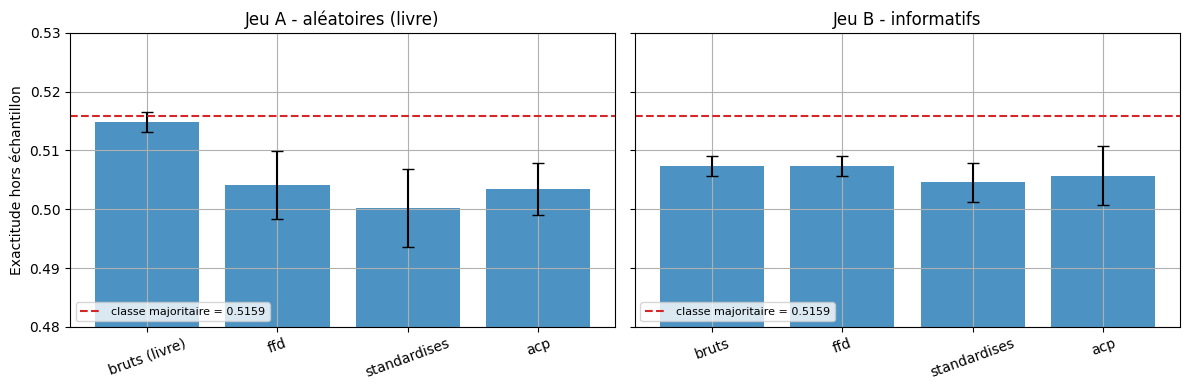

In [14]:
# Figure : exactitude par variante, avec la classe majoritaire de la fenêtre de test
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (titre, table) in zip(axes, (("Jeu A - aléatoires (livre)", resultats_random),
                                     ("Jeu B - informatifs", resultats_informative))):
    ax.bar(table["variante"], table["exactitude"], yerr=table["ecart_type"],
           capsize=4, color="tab:blue", alpha=0.8)
    ax.axhline(float(table["majoritaire_test"].iloc[0]), color="tab:red", ls="--",
               label=f"classe majoritaire = {table['majoritaire_test'].iloc[0]:.4f}")
    ax.set_title(titre)
    ax.set_ylim(0.48, 0.53)
    ax.tick_params(axis="x", rotation=20)
    ax.legend(loc="lower left", fontsize=8)
axes[0].set_ylabel("Exactitude hors échantillon")
plt.tight_layout()
plt.show()

**Lecture du résultat.** La ligne rouge est la seule référence qui compte : prédire toujours la classe majoritaire de la fenêtre de test. Toutes les barres sont en dessous, et les barres d'erreur (un écart-type sur quatre graines) recouvrent la ligne rouge pour la variante « bruts » du jeu A. Le graphique ne montre donc pas quatre prétraitements d'inégale valeur : il montre quatre façons d'échouer à battre une règle triviale, chacune dans la marge de sa propre variance.

## Partie 7 — Ce que la mesure dit, et ce qu'elle ne dit pas

**Ce qui est établi par la mesure.** Sur cette cible (signe du rendement à 5 jours), avec ces facteurs et ce classifieur, aucun des quatre prétraitements du livre ne produit une exactitude hors échantillon supérieure à la classe majoritaire de la fenêtre de test. Le classement apparent des variantes est de l'ordre de la dispersion inter-graines.

**Ce qui explique le résultat, et qui est instructif.** Le jeu de facteurs du livre est tiré au hasard : il ne contient, par construction, **aucune** information sur la cible. Aucun prétraitement ne peut extraire d'un bruit l'information qui n'y est pas — au mieux il change la façon dont le modèle échoue. C'est pourquoi ce port ajoute un second jeu de facteurs, dérivés du prix : avec ceux-là, il y a bien de l'information dans les colonnes. Le résultat reste sous la majoritaire, ce qui déplace la question — le prétraitement n'est pas le levier ; la difficulté est dans la cible elle-même, un signe de rendement à cinq jours sur une série proche d'une martingale.

**Ce que la mesure ne dit pas.** Elle ne dit pas que la FFD, la standardisation ou l'ACP sont inutiles : elle dit qu'elles ne suffisent pas, et que le notebook du livre ne permet pas de conclure qu'elles aident, faute de référence. Elle ne dit rien non plus d'un autre actif, d'un autre horizon ou d'un autre modèle — la série synthétique est un banc d'essai contrôlé, pas une mesure de marché.

**Ce qu'il faudrait pour aller plus loin.** Une cible dont l'auto-corrélation est plus forte (horizon plus court, ou cible de tendance plutôt que de signe), une validation glissante plutôt qu'une découpe unique, et une comparaison à une règle naïve (acheter quand le momentum est positif). Ces trois pistes sont l'exercice 3.

### Exercice 3 — Une règle naïve bat-elle le modèle ?

Prenez les facteurs du jeu B, déjà standardisés. Construisez une règle sans apprentissage : prédire la classe 1 quand le momentum à 20 jours est positif. Comparez son exactitude à celle du tableau de la partie 6, sur la même fenêtre de test (les 25 % les plus récents).

**Indices**
- `# Indice` : la règle s'écrit `(facteurs[:, 0] > 0).astype(int)` sur la colonne du momentum 20
- `# Indice` : réutiliser `train_test_split(..., shuffle=False)` pour retrouver la même fenêtre
- `# Indice` : `accuracy_score(y_hat, y_test)`
- `# Etape 1` : découper la cible comme en partie 6
- `# Etape 2` : appliquer la règle de momentum sur la fenêtre de test
- `# Etape 3` : comparer à la majoritaire et au modèle

In [15]:
# Exercice 3 : une règle de momentum bat-elle le classifieur ?
# TODO etudiant : appliquer la règle momentum_20 > 0 sur la fenêtre de test
# Etape 1 : x_train, x_test, y_train, y_test = train_test_split(..., shuffle=False)
# Etape 2 : y_hat_naif = (x_test[:, 0] > 0).astype(int)
# Etape 3 : accuracy_score vs majoritaire et vs le tableau de la partie 6
exactitude_regle_naive = None  # TODO etudiant : remplacer par le calcul
print("Exercice a completer : règle de momentum contre le classifieur")

Exercice a completer : règle de momentum contre le classifieur


## Partie 8 — Référence : le code QuantBook du livre

La partie locale tourne sur une série synthétique. Pour rejouer l'exemple sur SPY réel, le code ci-dessous est celui du livre, à exécuter dans l'IDE Cloud (`https://www.quantconnect.com/research`) : l'environnement local ne dispose ni de `QuantBook` ni du flux de données historiques.

Le notebook complet du livre est `06 Applied Machine Learning/02 Factor Preprocessing Techniques for Regime Detection/research.ipynb`, dépôt `QuantConnect/HandsOnAITradingBook`, commit `e025f21`.

In [16]:
# [REFERENCE QC CLOUD] Code à exécuter dans l'IDE Cloud, non exécutable ici
qc_reference_code = '''
from AlgorithmImports import *
import plotly.graph_objects as go

# Ouvre un QuantBook et charge SPY en journalier.
qb = QuantBook()
symbol = qb.add_equity("SPY", Resolution.DAILY).symbol
history = qb.history(symbol, datetime(2000, 1, 1), datetime(2024, 1, 1))

# Cible : le prix a-t-il monte dans les cinq jours qui suivent ?
label = history.loc[symbol]["open"].pct_change(5).shift(-5).dropna().apply(
    lambda x: int(x > 0)
)

go.Figure(
    go.Scatter(
        x=label.index, y=history.loc[symbol]["open"], mode="markers",
        marker=dict(color=["blue" if x else "red" for x in label.values], size=3)
    ),
    dict(title="Label Distribution", xaxis_title="Date", yaxis_title="Price")
).show()
print(label.value_counts())

# Les facteurs du livre sont tires au hasard, pour montrer l'effet mecanique
# du pretraitement -- pas pour mesurer une performance.
import numpy as np
np.random.seed(2)
num_factors, num_samples = 4, len(label)
factors = np.random.rand(num_samples, num_factors)
factors[:, -1] = factors[:, -1].cumsum()   # facteur non stationnaire
'''

print(f"Référence QuantBook conservée ({len(qc_reference_code.splitlines())} lignes).")
print("À exécuter dans l'IDE Cloud : qb.history n'existe pas hors QuantConnect.")

Référence QuantBook conservée (30 lignes).
À exécuter dans l'IDE Cloud : qb.history n'existe pas hors QuantConnect.


## Conclusion

| Ce qui a été porté | Ce qui a été mesuré en plus |
|---|---|
| Les cinq parties du livre : cible à 5 jours, facteurs bruts, FFD, standardisation, ACP | La classe majoritaire **de la fenêtre de test**, référence absente du livre |
| Le classifieur `lightgbm` en mode forêt et la découpe `shuffle=False` | La **part de classe 1 prédite**, qui sépare un modèle qui discrimine d'un modèle qui recopie |
| La FFD à fenêtre fixe (López de Prado), fidèlement réimplémentée | La **dispersion sur quatre graines**, sans laquelle un écart de 0,01 n'est pas interprétable |
| La référence QC Cloud pour rejouer sur SPY réel | Un **second jeu de facteurs informatifs**, qui déplace la question du prétraitement vers la cible |

**Résultat principal** : aucun des quatre prétraitements ne dépasse la classe majoritaire de la fenêtre de test, ni sur les facteurs aléatoires du livre ni sur des facteurs dérivés du prix. Le classement apparent des variantes est du même ordre que la dispersion inter-graines. La FFD, en particulier, ne transforme qu'un facteur sur quatre dans le jeu du livre et aucun dans un jeu de facteurs déjà stationnaires.

**Suite** : l'issue #18958 demandait le port et la mesure face à la classe majoritaire ; les deux sont livrés. L'inventaire `BOOK_MAPPING.md` passe la ligne `06/02` de `GAP` à `COVERED`.
